# Number Prediction Model — Google Colab Walkthrough

**Lumexa Python & AI Foundations course**

Predict a student's test score from the number of hours they studied, using a linear
regression model built with scikit-learn.

This notebook is fully self-contained and works with **Runtime → Run all** — no setup,
no API keys, and no files to upload. The dataset is generated directly in the notebook.

**What you'll do:**
1. Generate a realistic synthetic dataset (hours studied vs. test score)
2. Split the data into training and test sets
3. Train a linear regression model
4. Evaluate the model honestly using MSE and R²
5. Visualize the results
6. Use the trained model to make predictions on new data


In [1]:
# All packages used below (numpy, scikit-learn, matplotlib) are preinstalled in Google Colab.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
print("Libraries loaded.")

Libraries loaded.


## Step 1: Generate a synthetic dataset

We simulate a dataset where `test_score` follows a roughly linear relationship with
`hours_studied`, plus realistic random noise, clipped to a valid 0-100 score range.

In [2]:
NUM_SAMPLES = 200
NOISE_LEVEL = 6.0
RANDOM_SEED = 42
BASE_SCORE = 42.0
HOURS_COEFFICIENT = 5.1

rng = np.random.default_rng(RANDOM_SEED)
hours_studied = np.round(rng.uniform(0.0, 12.0, size=NUM_SAMPLES), 2)
noise = rng.normal(0.0, NOISE_LEVEL, size=NUM_SAMPLES)
test_scores = np.clip(BASE_SCORE + HOURS_COEFFICIENT * hours_studied + noise, 0, 100)
test_scores = np.round(test_scores, 1)

print(f'Generated {NUM_SAMPLES} samples.')
print('First 5 rows:')
for i in range(5):
    print(f'  hours_studied={hours_studied[i]:.2f}, test_score={test_scores[i]:.1f}')

Generated 200 samples.
First 5 rows:
  hours_studied=9.29, test_score=93.2
  hours_studied=5.27, test_score=66.5
  hours_studied=10.30, test_score=94.5
  hours_studied=8.37, test_score=83.7
  hours_studied=1.13, test_score=49.8


## Step 2: Prepare features (X) and labels (y)

scikit-learn expects features `X` as a 2D array, so we reshape `hours_studied`.

In [3]:
X = hours_studied.reshape(-1, 1)
y = test_scores

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (200, 1)
y shape: (200,)


## Step 3: Split into training and test sets

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

Training samples: 160
Test samples: 40


## Step 4: Train the linear regression model

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Learned slope: {model.coef_[0]:.4f}')
print(f'Learned intercept: {model.intercept_:.4f}')
print(f'Formula: test_score = {model.intercept_:.2f} + {model.coef_[0]:.2f} * hours_studied')

Learned slope: 5.2790
Learned intercept: 40.2484
Formula: test_score = 40.25 + 5.28 * hours_studied


## Step 5: Evaluate the model honestly (train vs. test metrics)

In [6]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print(f'Training MSE: {train_mse:.2f}  |  Training R^2: {train_r2:.3f}')
print(f'Test MSE:     {test_mse:.2f}  |  Test R^2:     {test_r2:.3f}')

gap = train_r2 - test_r2
print(f'\nR^2 gap (train - test): {gap:.3f}')
if test_r2 > 0.6 and gap < 0.15:
    print('VERDICT: Good fit. The model generalizes well to unseen data.')
elif gap >= 0.15:
    print('VERDICT: Possible overfitting.')
else:
    print('VERDICT: Possible underfitting.')

Training MSE: 32.59  |  Training R^2: 0.910
Test MSE:     36.60  |  Test R^2:     0.878

R^2 gap (train - test): 0.032
VERDICT: Good fit. The model generalizes well to unseen data.


## Step 6: Visualize the results

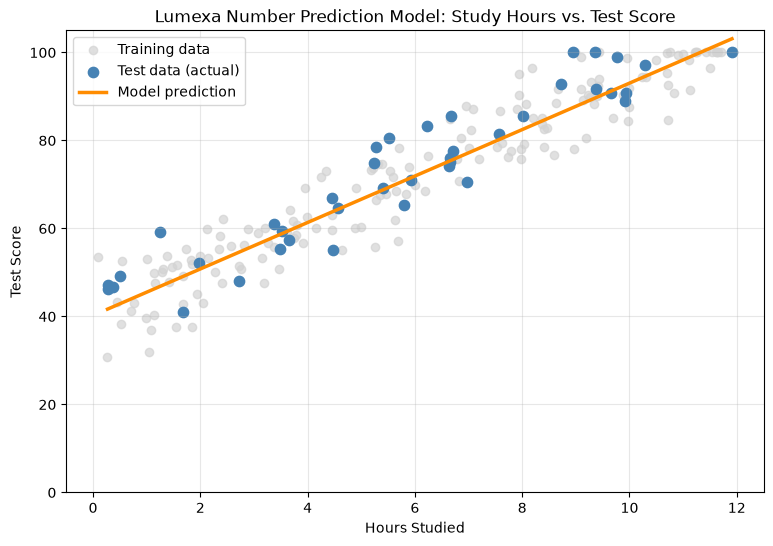

In [7]:
sort_order = np.argsort(X_test.flatten())
X_test_sorted = X_test[sort_order]
predictions_sorted = test_predictions[sort_order]

plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, color='lightgray', label='Training data', alpha=0.7)
plt.scatter(X_test, y_test, color='steelblue', label='Test data (actual)', s=55)
plt.plot(X_test_sorted, predictions_sorted, color='darkorange', linewidth=2.5, label='Model prediction')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.title('Lumexa Number Prediction Model: Study Hours vs. Test Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.show()

## Step 7: Use the model for inference on new data

In [8]:
new_hours = np.array([1.5, 4.0, 7.5, 10.0]).reshape(-1, 1)
new_predictions = np.clip(model.predict(new_hours), 0, 100)

for hours, prediction in zip(new_hours.flatten(), new_predictions):
    print(f'Hours studied: {hours:>5.1f}  ->  Predicted score: {prediction:6.1f}')

Hours studied:   1.5  ->  Predicted score:   48.2
Hours studied:   4.0  ->  Predicted score:   61.4
Hours studied:   7.5  ->  Predicted score:   79.8
Hours studied:  10.0  ->  Predicted score:   93.0


## Summary

This notebook covers a complete, real, end-to-end supervised machine learning
(regression) workflow: generating data, splitting it into train/test sets, training a
linear regression model, evaluating it honestly, visualizing results, and using the
model for inference on brand-new input.

**Try it yourself:** change `NOISE_LEVEL` in Step 1 above and re-run the notebook
(`Runtime → Run all`) to see how noisier data affects the training/test R² gap.